In [1]:
import numpy as np
import os, tqdm
import matplotlib.pyplot as plt
import corner

In [2]:
output_stat_dir = './SKA_chapter_statistics/'

In [3]:
# Astro params
params = ['ION_Tvir_MIN','R_BUBBLE_MAX','HII_EFF_FACTOR']
Fisher_Param = ['$T_{Vir}$','$R_{Max}$','$\zeta$']
nparams = len(params)
# parameter values for fiducial simulation
fid = np.array([10**4.7,15,30])

In [4]:
statname = 'ps'
model_files = {
    'AA* (100 h)' : os.path.join(output_stat_dir, f'posterior_covariance_matrix_AAstar_100hours_{statname}.txt'),
    'AA* (1000 h)': os.path.join(output_stat_dir, f'posterior_covariance_matrix_AAstar_1000hours_{statname}.txt'),
    'AA4 (1000 h)': os.path.join(output_stat_dir, f'posterior_covariance_matrix_AA4_1000hours_{statname}.txt'),
}

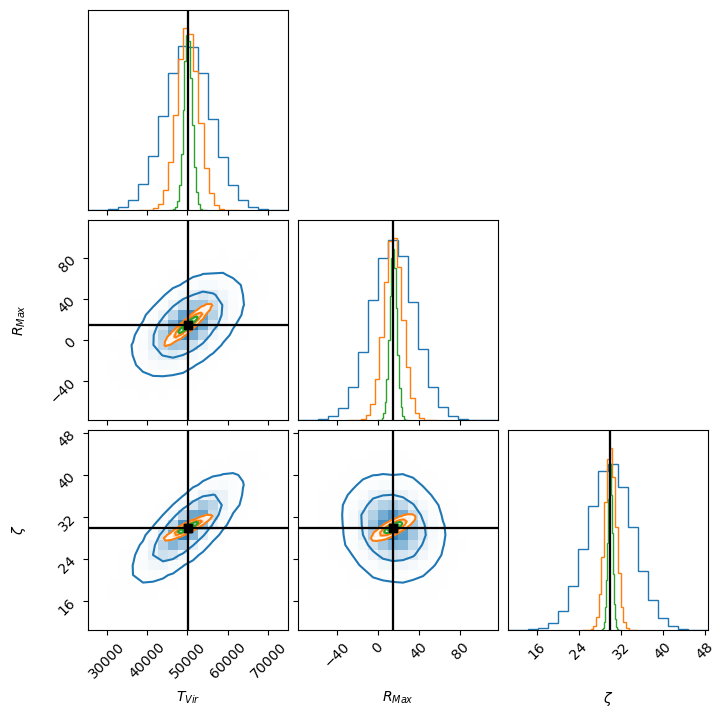

In [5]:
n_samples = 100000
fig = None 
for ii,name in enumerate(model_files.keys()):
    file = model_files[name]
    cov = np.loadtxt(file)
    fisher_samples = np.random.multivariate_normal(fid, cov, size=n_samples)
    fig = corner.corner(
            fisher_samples,
            fig=fig,
            labels=Fisher_Param,
            plot_datapoints=False,  
            levels=(0.68,0.95),
            truths=fid,
            truth_color='black', 
            color=f'C{ii}',           
        )

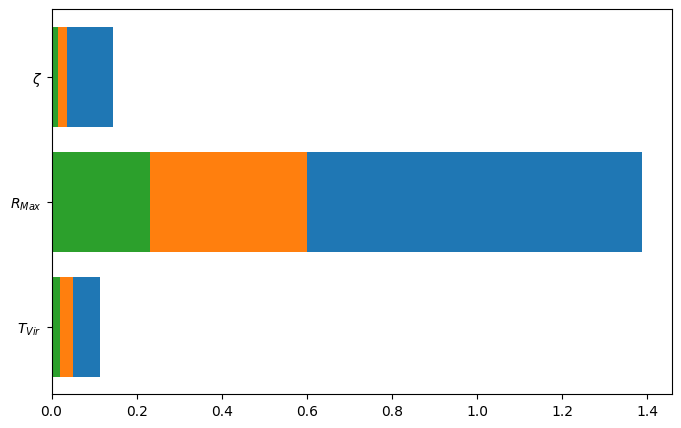

In [19]:
plt.figure(figsize=(8, 5))
sig_normed = np.empty(len(model_files.keys()))
for ii,name in enumerate(model_files.keys()):
    file = model_files[name]
    cov = np.loadtxt(file)
    # sig_normed[ii] = np.diagonal(cov)/fid
    plt.barh(Fisher_Param, np.sqrt(np.diagonal(cov))/fid, color=f'C{ii}')
    